In [2]:
import os
from pathlib import Path
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

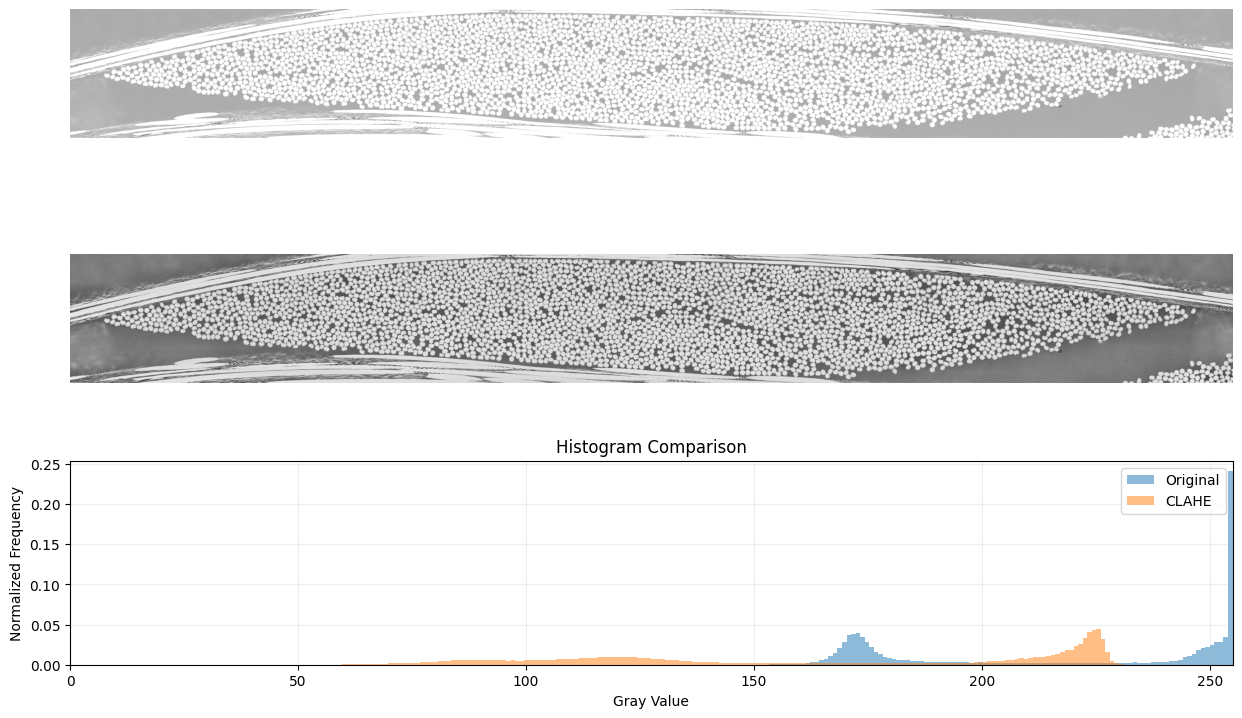

In [4]:
file_path = Path("../../data/promotion/245_004.tif")

img_np = np.array(Image.open(file_path).convert("L"))

thresh =50

def contrast_stretch(img, p_low=1, p_high=99):
    lo = np.percentile(img, p_low)
    hi = np.percentile(img, p_high)

    img_cs = (img - lo) / (hi - lo)
    img_cs = np.clip(img_cs, 0, 1)
    return (img_cs * 255).astype(np.uint8)

# img_eq = contrast_stretch(img_np, 1, 99)
# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16,16))
img_eq = clahe.apply(img_np-thresh)

# Plot both histograms in ONE figure
fig, ax = plt.subplots(3,1,figsize=(15,9))

ax[0].imshow(img_np,cmap="gray",vmin=0,vmax=255)
ax[0].axis("off")

ax[1].imshow(img_eq,cmap="gray",vmin=0,vmax=255)
ax[1].axis("off")


ax[2].hist(img_np.ravel(),
         bins=256,
         range=(0,255),
         alpha=0.5,
         label="Original",
         density=True)

ax[2].hist(img_eq.ravel(),
         bins=256,
         range=(0,255),
         alpha=0.5,
         label="CLAHE",
         density=True)

ax[2].set_xlim(0,255)
ax[2].set_xlabel("Gray Value")
ax[2].set_ylabel("Normalized Frequency")
ax[2].set_title("Histogram Comparison")
ax[2].legend()
ax[2].grid(alpha=0.2)

plt.show()
output_path = file_path.parent / f"{file_path.stem}.adj.tif"
img_pil = Image.fromarray(img_eq.astype(np.uint8)).convert("L")

img_pil.save(output_path)
# --- 3) Half resolution ---
w, h = img_pil.size
half_size = (max(1, w // 2), max(1, h // 2))

# For downsampling, BOX is a good averaging filter (often best for microscopy)
img_half  = img_pil.resize(half_size, resample=Image.Resampling.BOX)
output_path = file_path.parent / f"{file_path.stem}.adj.red.png"
img_half.save(output_path,dpi=(72,72))